# Evaluation

This notebook compares every model from the frequency, severity and pure premium notebooks in the way a pricing team would. It uses only the **frozen test-set predictions** those notebooks saved: nothing is refitted and no choice is made here, so the test set is still used only once.

It covers:

1. why deviance rather than RMSE;
2. one comparison table for every model;
3. whether the differences between models are larger than sampling noise;
4. risk ranking (Lorenz curve and Gini), calibration and overall balance;
5. double-lift charts, which show where two models disagree and which is right;
6. a check of the Poisson assumption behind the frequency GLM.

All metrics are exposure-weighted, except severity, which is weighted by number of claims.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from pricing.data import LARGE_LOSS_CAP, PROJECT_ROOT, build_policy_table, load_raw, severity_rows, split_train_test
from pricing.evaluation import (
    balance, bootstrap_difference, calibration_table, double_lift_table, gamma_deviance, gini, lorenz_curve,
    pearson_dispersion, poisson_deviance, top_share, tweedie_deviance,
)
from pricing.features import add_glm_bands, glm_design_matrix
from pricing.glm import predict
from pricing.plots import plot_calibration, plot_double_lift, plot_lorenz, save, set_style

set_style()
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(4)
PROCESSED = PROJECT_ROOT / "data" / "processed"
POWER = 1.8

In [2]:
freq = pl.read_parquet(PROCESSED / "frequency_test_predictions.parquet")
sev = severity_rows(pl.read_parquet(PROCESSED / "severity_test_predictions.parquet"))
pp = pl.read_parquet(PROCESSED / "pure_premium_test_predictions.parquet")

# Training averages, for the "no factors" benchmark each model is compared with.
freq_raw, sev_raw = load_raw()
train, _ = split_train_test(build_policy_table(freq_raw, sev_raw, large_loss_cap=LARGE_LOSS_CAP))
train_sev = severity_rows(train)
null = {
    "frequency": train["ClaimNb"].sum() / train["Exposure"].sum(),
    "severity": train_sev["ClaimAmount"].sum() / train_sev["SevNb"].sum(),
    "pure premium": train["ClaimAmount"].sum() / train["Exposure"].sum(),
}
null

{'frequency': 0.07325538219707055,
 'severity': 1743.409240638662,
 'pure premium': 127.9390553661939}

## 1. Why deviance, not RMSE

RMSE squares each error, so it is dominated by the largest ones. Claim cost is zero for 96% of policies and occasionally very large, so a handful of policies decide the RMSE. The cell below scores the two frequency x severity models and a model with no factors at all (the training average for everyone) on pure premium.

In [3]:
cost, expo = pp["ClaimAmount"].to_numpy(), pp["Exposure"].to_numpy()
rate = cost / expo
candidates = {"no factors": np.full(len(cost), null["pure premium"]),
              "GLM freq x sev": pp["pp_glm_fs"].to_numpy(), "GBM freq x sev": pp["pp_gbm_fs"].to_numpy()}
pl.DataFrame([
    {"model": m, "RMSE (EUR per policy-year)": float(np.sqrt(np.average((rate - p) ** 2, weights=expo))),
     f"Tweedie deviance p{POWER}": tweedie_deviance(cost, p, expo, POWER)}
    for m, p in candidates.items()
])

model,RMSE (EUR per policy-year),Tweedie deviance p1.8
str,f64,f64
"""no factors""",3147.4504,30.7583
"""GLM freq x sev""",3145.7967,29.9225
"""GBM freq x sev""",3144.9790,29.6123


In [4]:
sq_err = np.sort(expo * (rate - pp["pp_gbm_fs"].to_numpy()) ** 2)[::-1]
print(f"Share of the GBM's squared error from its 10 worst policies:  {sq_err[:10].sum() / sq_err.sum():.0%}")
print(f"Share of the GBM's squared error from its 100 worst policies: {sq_err[:100].sum() / sq_err.sum():.0%}")
print(f"Test policies: {len(sq_err):,}")

Share of the GBM's squared error from its 10 worst policies:  55%
Share of the GBM's squared error from its 100 worst policies: 93%
Test policies: 135,603


By RMSE the three models are within 0.1% of each other, so it cannot tell a real pricing model from charging everyone the average. More than half of the squared error comes from ten policies out of 135,000: RMSE is measuring how badly each model missed a few large claims, which no model can predict.

**Deviance** measures fit in the way that matches how the data is generated. For each distribution it is twice the gap in log-likelihood between the model and a perfect fit, so it judges errors against the variance that distribution expects at each prediction: a miss on a policy with a high predicted cost is expected to be larger, and counts for less. Poisson deviance is used for claim counts, Gamma for cost per claim and Tweedie for pure premium. By deviance, both models are clearly better than no factors and the GBM is clearly better than the GLM.

## 2. One comparison table

Every model, scored on the test set with the same set of measures:

- **deviance**: the one that matches each stage (Poisson, Gamma, Tweedie at p = 1.8), lower is better;
- **deviance vs no factors**: the percentage reduction in deviance compared with charging everyone the training average;
- **Gini**: risk ranking, higher is better;
- **top 10% share**: the share of observed claims (or cost) in the 10% of exposure each model predicts to be riskiest, which is one way to read the Gini;
- **balance**: total predicted over total observed.

In [5]:
def stage_rows(stage, observed, weight, preds, deviance, null_pred):
    null_dev = deviance(observed, null_pred, weight)
    rows = []
    for model, pred in {"no factors": null_pred, **preds}.items():
        dev = deviance(observed, pred, weight)
        rows.append({
            "stage": stage, "model": model, "deviance": dev, "vs_no_factors": 1 - dev / null_dev,
            "gini": gini(observed, pred, weight), "top_10pct_share": top_share(observed, pred, weight),
            "balance": balance(observed, pred, weight),
        })
    return rows


y_freq, e_freq = freq["ClaimNb"].to_numpy(), freq["Exposure"].to_numpy()
y_sev, w_sev = sev["ClaimAmount"].to_numpy(), sev["SevNb"].to_numpy().astype(float)
freq_preds = {"GLM": freq["freq_glm"].to_numpy(), "GBM": freq["freq_gbm"].to_numpy()}
sev_preds = {"GLM": sev["sev_glm"].to_numpy(), "GBM": sev["sev_gbm"].to_numpy()}
pp_preds = {"GLM freq x sev": pp["pp_glm_fs"].to_numpy(), "GBM freq x sev": pp["pp_gbm_fs"].to_numpy(),
            "GLM Tweedie": pp["pp_glm_tweedie"].to_numpy(), "GBM Tweedie": pp["pp_gbm_tweedie"].to_numpy()}

comparison = pl.DataFrame(
    stage_rows("frequency (Poisson)", y_freq, e_freq, freq_preds, poisson_deviance, np.full(len(y_freq), null["frequency"]))
    + stage_rows("severity (Gamma)", y_sev, w_sev, sev_preds,
                 lambda o, p, w: gamma_deviance(o / w, p, w), np.full(len(y_sev), null["severity"]))
    + stage_rows(f"pure premium (Tweedie {POWER})", cost, expo, pp_preds,
                 lambda o, p, w: tweedie_deviance(o, p, w, POWER), np.full(len(cost), null["pure premium"]))
)
comparison

stage,model,deviance,vs_no_factors,gini,top_10pct_share,balance
str,str,f64,f64,f64,f64,f64
"""frequency (Poisson)""","""no factors""",0.4858,0.0000,-0.0599,0.0852,0.9716
"""frequency (Poisson)""","""GLM""",0.4625,0.0478,0.2931,0.2475,0.9731
"""frequency (Poisson)""","""GBM""",0.4543,0.0648,0.3261,0.2851,0.9704
"""severity (Gamma)""","""no factors""",1.2381,0.0000,0.0084,0.0940,0.9702
"""severity (Gamma)""","""GLM""",1.2449,-0.0055,0.0141,0.1322,0.9723
"""severity (Gamma)""","""GBM""",1.2346,0.0028,0.0366,0.1275,0.9545
"""pure premium (Tweedie 1.8)""","""no factors""",30.7583,0.0000,-0.0520,0.0832,0.9440
"""pure premium (Tweedie 1.8)""","""GLM freq x sev""",29.9225,0.0272,0.3112,0.2699,0.9449
"""pure premium (Tweedie 1.8)""","""GBM freq x sev""",29.6123,0.0373,0.3537,0.3093,0.9240


Reading across the stages:

- **Frequency is where the models earn their keep.** Both beat no factors by a clear margin, and the GBM beats the GLM on deviance, Gini and top 10% share. Their balance is almost the same.
- **Severity adds little.** Neither model is much better than the training average, as the severity notebook found; the GLM is slightly worse than no factors on this test set.
- **Pure premium follows frequency.** The GBM frequency x severity model is best. The two GLMs are close to each other.
- **The no-factor model's Gini is not exactly zero** (it is slightly negative) because every policy gets the same prediction, so the order they are sorted in is arbitrary. Read it as zero.
- **Balance is below 1 for every model, including no factors.** The test set happens to have about 3% more claims and 6% more capped cost per policy-year than training. Because the no-factor model shows the same gap, this is the split, not the models.

## 3. Are the differences real?

The differences in deviance and Gini are small numbers, so they need a sense of scale. Each comparison below resamples the test policies 200 times with replacement, scores both models on the same resample, and reports a 95% interval for the difference. An interval that excludes zero means the difference is unlikely to be sampling noise.

In [6]:
tw = lambda o, p, w: tweedie_deviance(o, p, w, POWER)
sev_dev = lambda o, p, w: gamma_deviance(o / w, p, w)
pairs = [
    ("frequency", "GLM", "GBM", y_freq, e_freq, freq_preds, poisson_deviance),
    ("severity", "GLM", "GBM", y_sev, w_sev, sev_preds, sev_dev),
    ("pure premium", "GLM freq x sev", "GBM freq x sev", cost, expo, pp_preds, tw),
    ("pure premium", "GLM freq x sev", "GLM Tweedie", cost, expo, pp_preds, tw),
    ("pure premium", "GBM freq x sev", "GBM Tweedie", cost, expo, pp_preds, tw),
]
rows = []
for stage, a, b, obs, w, preds, dev in pairs:
    g, g_lo, g_hi = bootstrap_difference(gini, obs, preds[a], preds[b], w)
    d, d_lo, d_hi = bootstrap_difference(dev, obs, preds[a], preds[b], w)
    rows.append({"stage": stage, "comparison": f"{b} minus {a}", "gini_diff": g, "gini_low": g_lo, "gini_high": g_hi,
                 "deviance_diff": d, "deviance_low": d_lo, "deviance_high": d_hi})
pl.DataFrame(rows)

stage,comparison,gini_diff,gini_low,gini_high,deviance_diff,deviance_low,deviance_high
str,str,f64,f64,f64,f64,f64,f64
"""frequency""","""GBM minus GLM""",0.0330,0.0247,0.0409,-0.0082,-0.0097,-0.0066
"""severity""","""GBM minus GLM""",0.0225,-0.0099,0.0575,-0.0103,-0.0271,0.0052
"""pure premium""","""GBM freq x sev minus GLM freq …",0.0425,0.0250,0.0628,-0.3103,-0.4542,-0.1903
"""pure premium""","""GLM Tweedie minus GLM freq x s…",0.0057,-0.0046,0.0168,0.0039,-0.0594,0.0768
"""pure premium""","""GBM Tweedie minus GBM freq x s…",-0.0237,-0.0361,-0.0122,0.1693,0.0915,0.2733


A positive Gini difference and a negative deviance difference both favour the second model.

- **GBM over GLM for frequency and for pure premium**: both intervals exclude zero, for Gini and for deviance. The GBM's advantage is not an accident of which policies ended up in the test set.
- **GBM over GLM for severity**: the intervals include zero. There is no reliable difference.
- **Tweedie against frequency x severity**: for the GLMs the difference is not distinguishable from noise. For the GBMs, frequency x severity is better, and that interval excludes zero.

## 4. Risk ranking, calibration and balance

### Lorenz curve and Gini

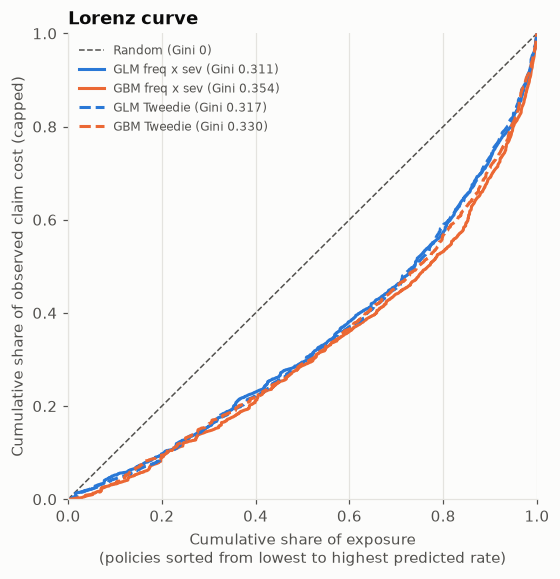

In [7]:
fig = plot_lorenz(
    {m: lorenz_curve(cost, p, expo) for m, p in pp_preds.items()},
    {m: gini(cost, p, expo) for m, p in pp_preds.items()},
    ylabel="Cumulative share of observed claim cost (capped)",
)
save(fig, "eval_lorenz_pure_premium")
plt.show()

The Lorenz curve sorts policies from lowest to highest predicted pure premium and plots the share of actual claim cost they account for against their share of exposure. A model with no information gives the diagonal; the further the curve sags below it, the better the model separates cheap risks from expensive ones. The Gini is twice the area between the diagonal and the curve.

What a Gini of about 0.3 means in practice is easier to see in the top 10% share column above: the 10% of exposure the GLM rates as riskiest produces about a quarter of all claims, and for the GBM a bit more. With no ranking ability, it would produce 10%.

### Calibration

Calibration checks whether predictions are right in level across the range, not only on average. Policies are sorted by predicted pure premium and cut into ten bands of equal exposure.

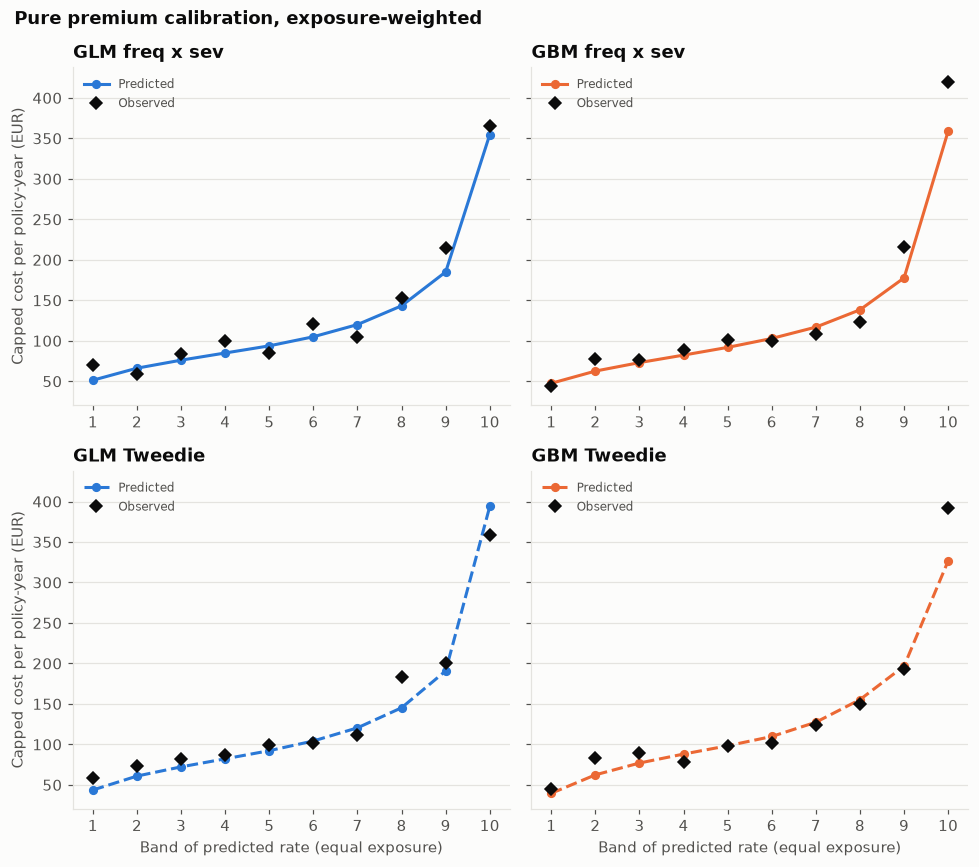

In [8]:
fig = plot_calibration(
    {m: calibration_table(cost, p, expo) for m, p in pp_preds.items()},
    ylabel="Capped cost per policy-year (EUR)", title="Pure premium calibration, exposure-weighted",
)
save(fig, "eval_calibration_pure_premium")
plt.show()

All four models track the observed cost across the bands and are furthest out in the top band, the most expensive policies. The pure premium notebook discusses this chart in more detail.

### Balance

Balance is the whole-portfolio check: does the model predict the right total? It is in the comparison table above. Every model, including no factors, predicts 3 to 8% less than the test set's capped cost, because the test set is slightly more expensive than training. A pricing team would check balance on each new period of data and rebase the model if the gap persisted, since a model that ranks well but charges the wrong overall level still loses money.

## 5. Double-lift charts

Deviance and Gini say which model is better overall. They do not say **where** two models disagree, or which one is right there. A double-lift chart does:

1. For each policy, take the ratio of the two models' predictions (here GBM / GLM).
2. Sort policies by that ratio and cut them into ten bands of equal exposure. Band 1 is where the GBM is lowest relative to the GLM; band 10 is where it is highest.
3. In each band, plot the observed value and each model's prediction. Each series is divided by its own portfolio average, so only the shape is compared, not the overall level.

If the observed points follow the GBM's line, the policies the GBM re-rates really are riskier (or safer) than the GLM thinks.

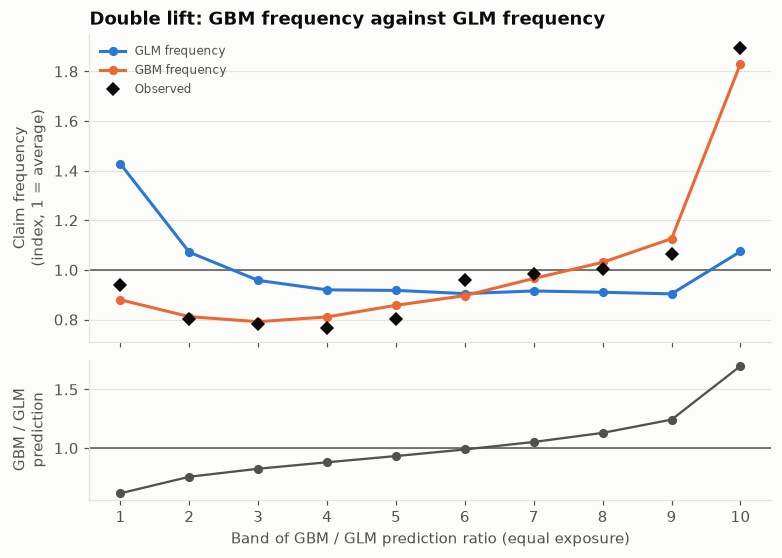

band,weight,ratio_b_to_a,observed_index,a_index,b_index,observed_over_a,observed_over_b
i64,f64,f64,f64,f64,f64,f64,f64
1,7159.5245,0.6147,0.9411,1.4269,0.8795,0.6778,1.1026
2,7158.7740,0.7556,0.8041,1.0710,0.8115,0.7715,1.0211
3,7160.3710,0.8240,0.7835,0.9577,0.7914,0.8407,1.0203
4,7159.6975,0.8789,0.7669,0.9196,0.8106,0.8570,0.9751
5,7159.1798,0.9320,0.8003,0.9174,0.8574,0.8965,0.9619
6,7159.8654,0.9883,0.9596,0.9046,0.8965,1.0901,1.1031
7,7159.4760,1.0521,0.9837,0.9152,0.9656,1.1045,1.0499
8,7159.8348,1.1295,1.0022,0.9099,1.0307,1.1318,1.0020
9,7159.6460,1.2427,1.0634,0.9035,1.1259,1.2094,0.9732


In [9]:
dl_freq = double_lift_table(y_freq, freq_preds["GLM"], freq_preds["GBM"], e_freq)
fig = plot_double_lift(dl_freq, "GLM frequency", "GBM frequency", "Claim frequency\n(index, 1 = average)")
save(fig, "eval_double_lift_frequency")
plt.show()
dl_freq.select("band", "weight", "ratio_b_to_a", "observed_index", "a_index", "b_index", "observed_over_a", "observed_over_b")

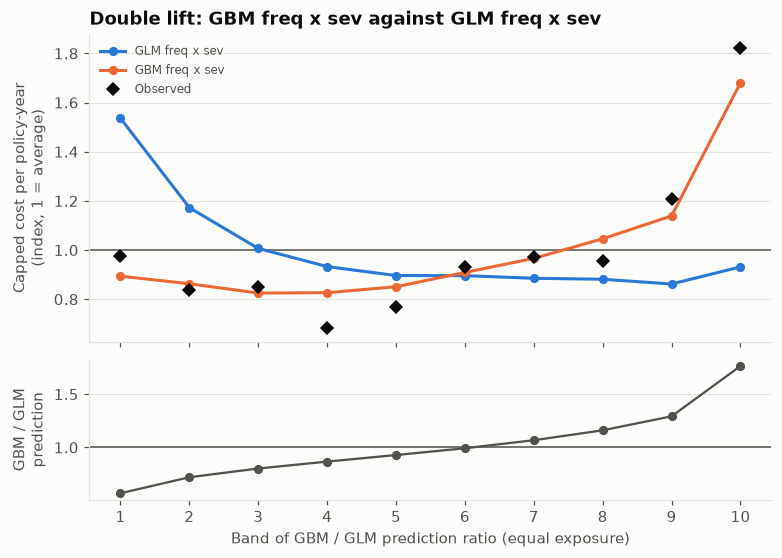

band,weight,ratio_b_to_a,observed_index,a_index,b_index,observed_over_a,observed_over_b
i64,f64,f64,f64,f64,f64,f64,f64
1,7158.9506,0.5690,0.9748,1.5360,0.8938,0.6717,1.1803
2,7159.7803,0.7197,0.8361,1.1726,0.8630,0.7547,1.0486
3,7160.0655,0.8016,0.8509,1.0065,0.8251,0.8947,1.1161
4,7159.5912,0.8666,0.6840,0.9328,0.8267,0.7761,0.8955
5,7159.5813,0.9283,0.7695,0.8963,0.8508,0.9086,0.9788
6,7159.3077,0.9921,0.9291,0.8959,0.9089,1.0976,1.1064
7,7159.6682,1.0674,0.9709,0.8852,0.9662,1.1608,1.0875
8,7159.6628,1.1606,0.9555,0.8813,1.0459,1.1475,0.9887
9,7159.8142,1.2920,1.2065,0.8620,1.1389,1.4813,1.1465


In [10]:
dl_pp = double_lift_table(cost, pp_preds["GLM freq x sev"], pp_preds["GBM freq x sev"], expo)
fig = plot_double_lift(dl_pp, "GLM freq x sev", "GBM freq x sev", "Capped cost per policy-year\n(index, 1 = average)")
save(fig, "eval_double_lift_pure_premium")
plt.show()
dl_pp.select("band", "weight", "ratio_b_to_a", "observed_index", "a_index", "b_index", "observed_over_a", "observed_over_b")

Both charts tell the same story. In the band where the GBM's prediction is highest relative to the GLM's (band 10, where it is about 1.7 times the GLM's), observed frequency is about 1.9 times average; the GBM predicted about 1.8 and the GLM about 1.1. In that band the GLM under-predicts claims by roughly 80% (the `observed_over_a` column is observed divided by the GLM's prediction). At the other end, in band 1, the GBM predicts about 40% less than the GLM, and observed frequency is close to the GBM's line: the GLM over-predicts there by about 50% (observed is about two thirds of its prediction).

Across the middle bands the observed points mostly sit closer to the GBM's line than to the GLM's. The GBM's extra differentiation is real, and it is concentrated at the two ends. These are the policies to look at when asking what the GBM has found that the GLM has not, which is the subject of the commercial analysis notebook.

The pure premium chart is noisier, because claim cost is noisier than claim counts, but the pattern is the same and slightly stronger at the top: in band 10 the GLM's predicted cost is about half of what was observed.

## 6. Is the Poisson assumption reasonable?

A Poisson model assumes the variance of claim counts equals their mean. If the data varies more than that (**overdispersion**), predictions are unaffected but the GLM's standard errors and confidence intervals are too narrow. The check is the Pearson dispersion: the sum of squared standardised residuals divided by the residual degrees of freedom. It should be about 1.

In [11]:
with open(PROCESSED / "frequency_glm.pkl", "rb") as fh:
    freq_glm = pickle.load(fh)
X_train = glm_design_matrix(add_glm_bands(train), freq_glm["levels"], freq_glm["base"])
train_rate = predict(freq_glm["results"], X_train)
phi_train = pearson_dispersion(train["ClaimNb"].to_numpy(), train_rate, train["Exposure"].to_numpy(), X_train.shape[1])
phi_test = pearson_dispersion(y_freq, freq_preds["GLM"], e_freq, X_train.shape[1])
print(f"Pearson dispersion, training: {phi_train:.2f}   test: {phi_test:.2f}")
print(f"Confidence intervals should be about {np.sqrt(phi_train) - 1:.0%} wider than the Poisson GLM reports")

Pearson dispersion, training: 1.72   test: 1.71
Confidence intervals should be about 31% wider than the Poisson GLM reports


The dispersion is about 1.7, on training and test alike, so claim counts vary more than a Poisson model allows. That is common in claims data: policies within the same rating cell still differ in ways the factors do not capture, which adds variance.

It does not change the predicted frequencies, and so none of the comparisons above. It does mean the 95% intervals on the frequency relativities in the frequency notebook are too narrow, by about 30%. A quasi-Poisson model (same coefficients, standard errors scaled by the square root of the dispersion) or a negative binomial model would give honest intervals. The practical consequence is that a few relativities that looked clearly different from 1, such as some regions, may not be.